# 🐟 Fisheries Stock Assessment: ML for Sustainable Marine Management

**Author:** Dean Wang | Lead Data & AI Engineer

**Government:** AFMA, CSIRO Oceans, DAFF, Fisheries Research & Development Corporation

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2000, 13)


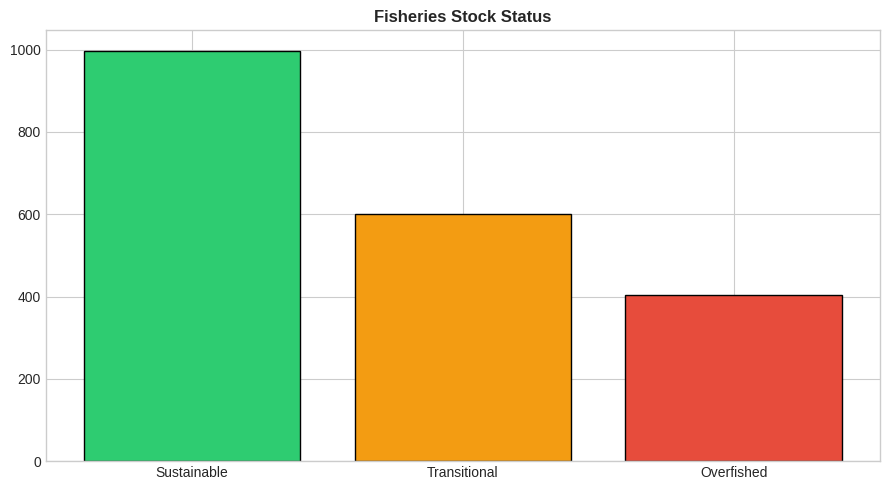

AU: AFMA manages Commonwealth fisheries worth $500M+. 3rd largest fishing zone globally (8.9M km2).


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2000,n_features=12,n_informative=9,n_classes=3,n_clusters_per_class=1,weights=[0.5,0.3,0.2],random_state=109)
names=['catch_per_unit_effort','spawning_biomass','recruitment_index','fishing_mortality','sea_temperature','plankton_abundance','bycatch_rate','fleet_size','gear_type','depth_zone','historical_catch_trend','protected_area_overlap']
df=pd.DataFrame(X_arr,columns=names);df['stock_status']=y;tc='stock_status'
tl=['Sustainable','Transitional','Overfished'];nc=3
print(f"Generated: {df.shape}");colors=['#2ecc71','#f39c12','#e74c3c']
fig,ax=plt.subplots(figsize=(9,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(nc),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(nc));ax.set_xticklabels(tl)
ax.set_title('Fisheries Stock Status',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: AFMA manages Commonwealth fisheries worth $500M+. 3rd largest fishing zone globally (8.9M km2).")

LogReg: Acc=0.8795 F1=0.8782 Kappa=0.8048
RF: Acc=0.9315 F1=0.9301 Kappa=0.8888
XGB: Acc=0.9400 F1=0.9394 Kappa=0.9030
LGBM: Acc=0.9440 F1=0.9435 Kappa=0.9095
Best: LGBM


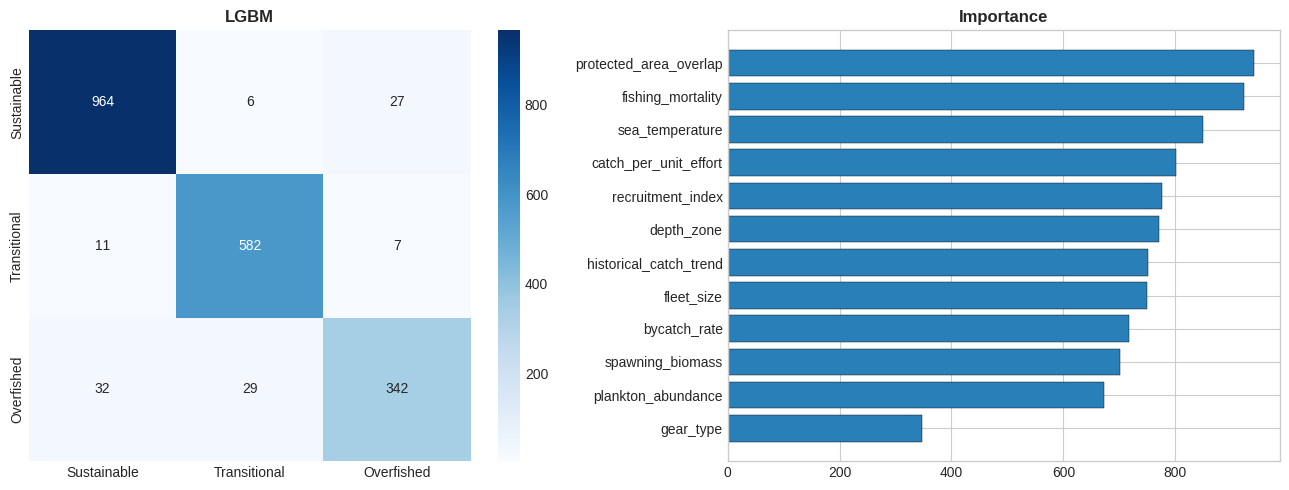

              precision    recall  f1-score   support

 Sustainable       0.96      0.97      0.96       997
Transitional       0.94      0.97      0.96       600
  Overfished       0.91      0.85      0.88       403

    accuracy                           0.94      2000
   macro avg       0.94      0.93      0.93      2000
weighted avg       0.94      0.94      0.94      2000

DEPLOYMENT: LGBM F1=0.9435 Kappa=0.9095 | AFMA logbooks + CSIRO surveys -> quota setting


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fk=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp,average='weighted'));fk.append(cohen_kappa_score(y2[vi],yp))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} Kappa={np.mean(fk):.4f}")
best=max(results,key=lambda k:results[k]['f1']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['f1']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#2980b9',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=tl))
br=results[best];print(f"DEPLOYMENT: {best} F1={br['f1']:.4f} Kappa={br['kappa']:.4f} | AFMA logbooks + CSIRO surveys -> quota setting")